In [1]:
NUM_AGENTS = 1
HEIGHT = 4
WIDTH = 4
SPAWN_PROB_PER_CELL = 0.05
DESPAWN_PROB_PER_CELL = 0.09

# Parameters
ENV_ITERATIONS = 100000
DISCOUNT = 0.99
EPSILON = 0.1
LEARNING_RATE = 0.00002
BATCH_SIZE = 32


HIDDEN_FEATURES = 128
HIDDEN_LAYERS = 4

In [2]:
import sys
sys.path.append("../..")
from models.value_cnn import ValueCNNCentralized
import numpy as np
from orchard.environment import Action2D, OrchardBasic
from tqdm import tqdm
import torch
from scipy.stats import norm
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

from models.value_cnn import Transition
from utils import ten_float
from dataclasses import dataclass
from typing import Any
from env_functions import *


--- PyTorch is configured to use: cuda ---


In [3]:
history = {
    "loss": [],
    "reward_mean": [],
    "reward_std": [],
    "target_mean": [],
    "target_std": [],
    "pred_mean": [],
    "pred_std": [],
    "corr": [],
}

def log_batch_stats(net: ValueCNNCentralized, batch_size: int):
    """Compute and store one-line summary statistics based on a sample from the replay buffer."""
    with torch.no_grad():
        if len(net.memory) < batch_size:
            return
            
        device = next(net.parameters()).device

        transitions = net.memory.sample(batch_size)
        batch = Transition(*zip(*transitions))

        states = ten_float(np.stack(batch.state), device=device)
        next_states = ten_float(np.stack(batch.new_state), device=device)
        rewards = ten_float(np.array(batch.reward), device=device)

        preds = net.forward(states).squeeze(1)
        
        # CORRECTED: use net.discount instead of net.trainer.discount
        targets = rewards + net.discount * net.target_net(next_states).squeeze(1)

        preds_np, targets_np, rewards_np = preds.cpu().numpy(), targets.cpu().numpy(), rewards.cpu().numpy()
        corr = np.corrcoef(preds_np, targets_np)[0, 1] if len(preds_np) > 1 else np.nan

    history["reward_mean"].append(np.mean(rewards_np))
    history["reward_std"].append(np.std(rewards_np))
    history["target_mean"].append(np.mean(targets_np))
    history["target_std"].append(np.std(targets_np))
    history["pred_mean"].append(np.mean(preds_np))
    history["pred_std"].append(np.std(preds_np))
    history["corr"].append(corr)
def state_to_raw_dict(s: State) -> dict:
    return {"apples": s.apples, "agents": s.agents}



In [4]:
def simulate_step(s: State, agent_idx: int, agent_positions: np.ndarray, action_vector: np.ndarray):
    """
    Simulates an agent taking an action. Does not modify in place.
    
    Returns:
        tuple: (reward: int, next_state: State, new_agent_positions: np.ndarray)
    """
    current_agents = s.agents
    current_apples = s.apples
    agent_pos = agent_positions[agent_idx]
    grid_shape = current_agents.shape
    
    new_position = np.clip(
        agent_pos + action_vector, [0, 0], np.array(grid_shape) - 1
    )
    
    next_agents = current_agents.copy()
    next_apples = current_apples.copy()
    
    next_agents[tuple(new_position)] += 1
    next_agents[tuple(agent_pos)] -= 1
    
    # The new positions array must be updated
    new_agent_positions = agent_positions.copy()
    new_agent_positions[agent_idx] = new_position
    
    reward = 0
    if next_apples[tuple(new_position)] > 0:
        next_apples[tuple(new_position)] -= 1
        reward = 1
        
    return reward, State(apples=next_apples, agents=next_agents), new_agent_positions

### Get CNN Centralized Estimate Value

In [5]:
def Q_team(s_t_plus_1: State, r_team: float, cnn: ValueCNNCentralized):
    return r_team + DISCOUNT * cnn.get_model_reward_prediction_from_raw(state_to_raw_dict(s_t_plus_1))

def argmax_a_of_Q_team(s_t, agent_idx: int, agent_positions: np.ndarray, value_CNN_centralized: ValueCNNCentralized):
    max_q = -float('inf')
    best_action = Action2D.STAY
    for action in Action2D:
        r_t, s_t_plus_1, new_agent_positions = simulate_step(s_t, agent_idx, agent_positions, action.vector)
        q_value = Q_team(s_t_plus_1, r_t, value_CNN_centralized)
        if q_value > max_q:
            max_q = q_value
            best_action = action
    return best_action

In [6]:
value_CNN_centralized = ValueCNNCentralized(HEIGHT, WIDTH, LEARNING_RATE, DISCOUNT, HIDDEN_FEATURES, HIDDEN_LAYERS)
s_0 = init_empty_state(HEIGHT, WIDTH)
place_agents_randomly(s_0, NUM_AGENTS)
agent_positions = np.argwhere(s_0.agents == 1)

TARGET_UPDATE_FREQUENCY = 100

total_steps = 0

s_t = s_0.copy()
for t in tqdm(range(ENV_ITERATIONS), desc="Training"):
    c = np.random.randint(0, len(agent_positions))
    
    p = np.random.random()
    if p < EPSILON:
        action = Action2D.get_random_action()
    else:
        action = argmax_a_of_Q_team(s_t, c, agent_positions, value_CNN_centralized)
        
    r_t, s_intermediate, agent_positions = simulate_step(s_t, c, agent_positions, action.vector)
    s_t_plus_1 = s_intermediate.copy()
    spawn_apples(s_t_plus_1, SPAWN_PROB_PER_CELL)
    despawn_apples(s_t_plus_1, DESPAWN_PROB_PER_CELL)

    # 1. Convert states to the network input format
    processed_s_t = value_CNN_centralized.raw_state_to_nn_input(state_to_raw_dict(s_t))
    processed_s_t_plus_1 = value_CNN_centralized.raw_state_to_nn_input(state_to_raw_dict(s_t_plus_1))

    # 2. Add the experience to the replay buffer
    value_CNN_centralized.add_experience(processed_s_t, processed_s_t_plus_1, r_t)

    # 3. Train on a batch ONLY if the buffer is large enough
    if len(value_CNN_centralized.memory) >= BATCH_SIZE:
        log_batch_stats(value_CNN_centralized, BATCH_SIZE)
        value_CNN_centralized.train_batch(BATCH_SIZE)
    
    # 4. Periodically update the target network
    if total_steps % TARGET_UPDATE_FREQUENCY == 0:
        value_CNN_centralized.update_target_net()

    s_t = s_t_plus_1
    total_steps += 1




Training: 100%|██████████| 100000/100000 [17:25<00:00, 95.69it/s] 


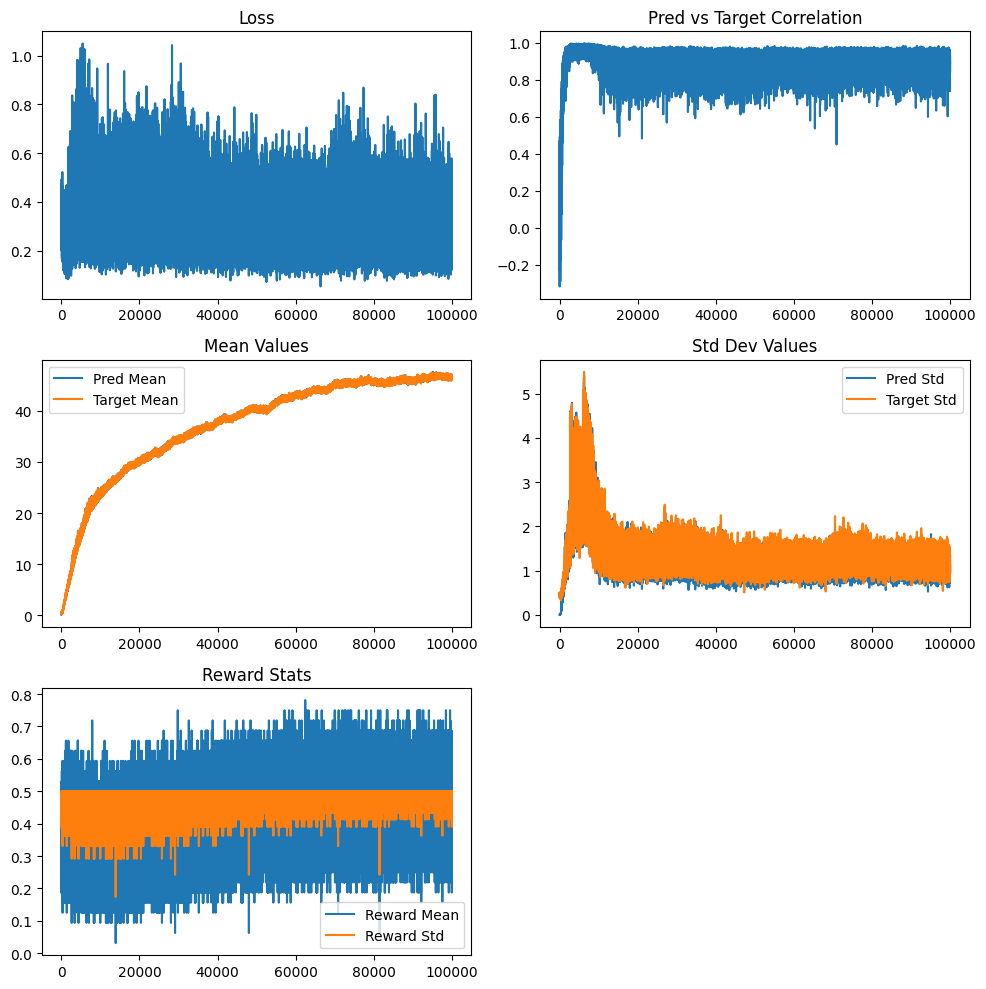

In [7]:
def plot_training_diagnostics(value_CNN_centralized):
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    axs = axs.flatten()

    axs[0].plot(value_CNN_centralized.loss_history)
    axs[0].set_title("Loss")

    axs[1].plot(history["corr"])
    axs[1].set_title("Pred vs Target Correlation")

    axs[2].plot(history["pred_mean"], label="Pred Mean")
    axs[2].plot(history["target_mean"], label="Target Mean")
    axs[2].set_title("Mean Values")
    axs[2].legend()

    axs[3].plot(history["pred_std"], label="Pred Std")
    axs[3].plot(history["target_std"], label="Target Std")
    axs[3].set_title("Std Dev Values")
    axs[3].legend()

    axs[4].plot(history["reward_mean"], label="Reward Mean")
    axs[4].plot(history["reward_std"], label="Reward Std")
    axs[4].set_title("Reward Stats")
    axs[4].legend()

    axs[5].axis("off")
    plt.tight_layout()
    plt.show()

plot_training_diagnostics(value_CNN_centralized)


In [8]:
def random_policy(s: State, agent_idx: int, agent_positions: np.ndarray):
    return Action2D.get_random_action()

def nearest_policy(s: State, agent_idx: int, agent_positions: np.ndarray):
    agent_pos = agent_positions[agent_idx]
    apple_positions = np.argwhere(s.apples > 0)
    if len(apple_positions) == 0:
        return Action2D.get_random_action()
    distances = np.linalg.norm(apple_positions - agent_pos, axis=1)
    nearest_apple_idx = np.argmin(distances)
    nearest_apple_pos = apple_positions[nearest_apple_idx]
    direction = nearest_apple_pos - agent_pos
    if abs(direction[0]) > abs(direction[1]):
        return Action2D.DOWN if direction[0] > 0 else Action2D.UP
    else:
        return Action2D.RIGHT if direction[1] > 0 else Action2D.LEFT

def optimal_learned_policy(s: State, agent_idx: int, agent_positions: np.ndarray):
    return argmax_a_of_Q_team(s, agent_idx, agent_positions, value_CNN_centralized)

In [9]:
def evaluate_policy(policy_func, num_steps: int = 1000):
    total_rewards = []
    s_0 = init_empty_state(HEIGHT, WIDTH)
    place_agents_randomly(s_0, NUM_AGENTS)
    agent_positions = np.argwhere(s_0.agents == 1)
    s_t = s_0.copy()
    for t in range(num_steps):  # fixed episode length
        c = np.random.randint(0, len(agent_positions))
        action = policy_func(s_t, c, agent_positions)
        r_t, s_intermediate, agent_positions = simulate_step(s_t, c, agent_positions, action.vector)
        s_t_plus_1 = s_intermediate.copy()
        spawn_apples(s_t_plus_1, SPAWN_PROB_PER_CELL)
        despawn_apples(s_t_plus_1, DESPAWN_PROB_PER_CELL)
        total_rewards.append(r_t)
        s_t = s_t_plus_1
    return total_rewards

In [10]:
random_rewards = evaluate_policy(random_policy, num_steps=1000)
nearest_rewards = evaluate_policy(nearest_policy, num_steps=1000)
learned_rewards = evaluate_policy(optimal_learned_policy, num_steps=1000)
print(f"Random Policy: Mean Reward = {np.mean(random_rewards):.4f}, Std Dev = {np.std(random_rewards):.4f}")
print(f"Nearest Policy: Mean Reward = {np.mean(nearest_rewards):.4f}, Std Dev = {np.std(nearest_rewards):.4f}")
print(f"Learned Policy: Mean Reward = {np.mean(learned_rewards):.4f}, Std Dev = {np.std(learned_rewards):.4f}")

Random Policy: Mean Reward = 0.1740, Std Dev = 0.3791
Nearest Policy: Mean Reward = 0.4920, Std Dev = 0.4999
Learned Policy: Mean Reward = 0.4760, Std Dev = 0.4994
